BA9: uncorrected... T = -3.161292279571532, p = [0.0031841152553567812]
BA46: uncorrected... T = -3.2133418242445946, p = [0.0031841152553567812, 0.002665670767689583]
HIP: uncorrected... T = -0.4863590865240654, p = [0.0031841152553567812, 0.002665670767689583, 0.6304777906120682]


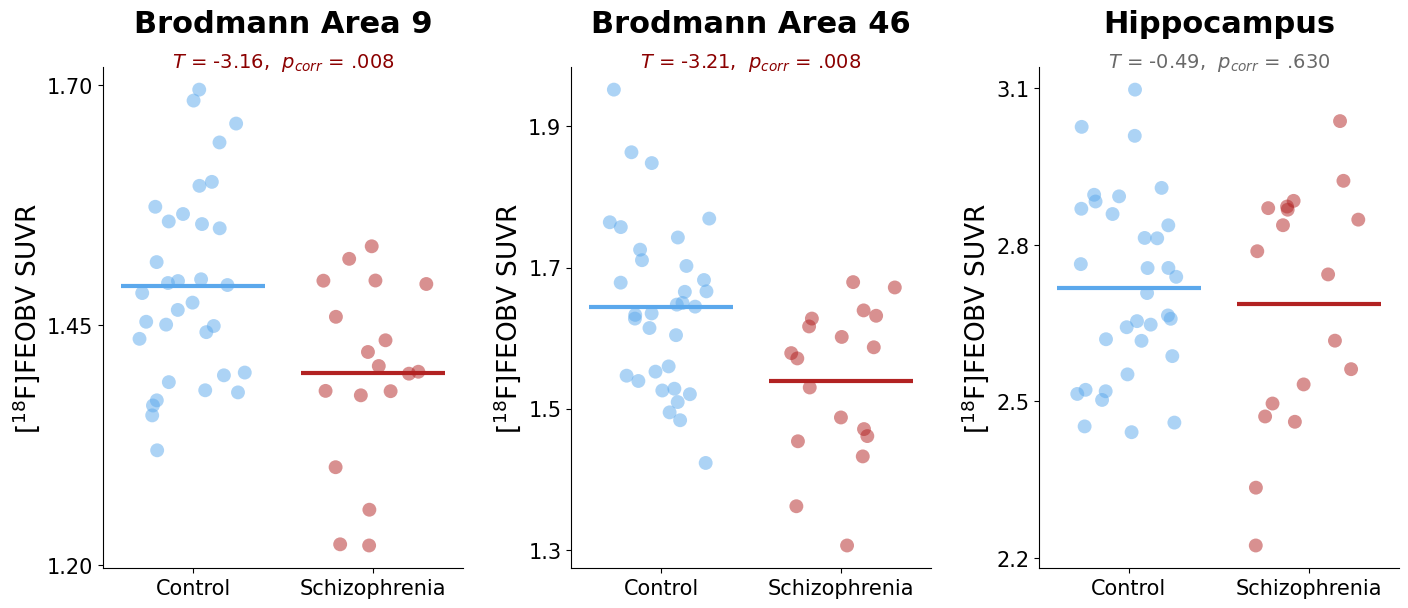

In [ ]:
####### Figure 1: Group differences between patients and controls, in BA9, BA46, and HIP SUVRs.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from scipy import stats
import pingouin as pg

## Colors
control_color = '#5BA8EC'
patient_color = '#B22222'

## ROI information (including labels and ticks)
ROI_info = {
	'BA9': {'label': 'Brodmann Area 9', 'ROI_ticks': [1.2, 1.45, 1.7]},
	'BA46': {'label': 'Brodmann Area 46', 'ROI_ticks': [1.3, 1.5, 1.7, 1.9]},
	'HIP': {'label': 'Hippocampus', 'ROI_ticks': [2.2, 2.5, 2.8, 3.1]},
}

## Load data
masterfile = pd.read_csv('data/masterfile_final_18patients_and_33controls.csv')

## T-test calculations
raw_p_values = []
t_stats = []
for ROI in ROI_info.keys():
	controls = masterfile[masterfile['Group'] == 'Control'][ROI]
	patients = masterfile[masterfile['Group'] == 'Schizophrenia'][ROI]
	raw_t_value, raw_p_value = stats.ttest_ind(patients, controls, equal_var=False)
	raw_p_values.append(raw_p_value)
	t_stats.append(raw_t_value)
	print(f"{ROI}: uncorrected... T = {raw_t_value}, p = {raw_p_values}")

## Correction for multiple comparisons (Holm-Bonferroni)
reject, p_corrected, alphac_sidak, alphac_bonf = multipletests(raw_p_values, method='holm') 	## bonferroni if want to be very conservative

## Create figure with 3 panels
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

# for ax, ROI in zip(axes, ROI_info.keys()):
for roi, (ax, ROI) in enumerate(zip(axes, ROI_info.keys())):
	## Plot group means
	group_means = masterfile.groupby('Group')[ROI].mean()
	for group, mean in group_means.items():
		color = control_color if group == 'Control' else patient_color
		x_position = 0 if group == 'Control' else 1
		ax.hlines(mean, xmin=x_position - 0.4, xmax=x_position + 0.4, color=color, lw=3)

	## Stripplot of individual values
	sns.stripplot(
		data=masterfile, x='Group', y=ROI, jitter=0.3, hue='Group',
		palette=sns.color_palette([control_color, patient_color]),
		alpha=0.5, size=10, ax=ax, dodge=False
	)
	if ax.legend_ is not None:
		ax.legend_.remove()

	## Corrected p values (Holm-Bonferroni)
	t_val = t_stats[roi]
	p_val = p_corrected[roi]

	## Formatting
	t_text = f"$\\mathit{{T}}$ = {t_val:.2f}"
	if p_val < 0.001:
		p_text = "$\\mathit{p}_{corr}$ < .001"
	else:
		p_str = f"{p_val:.3f}".replace('0.', '.')
		p_text = f"$\\mathit{{p}}_{{corr}}$ = {p_str}"

	stats_color = 'darkred' if reject[roi] else 'dimgray'
	ax.text(0.5, 1.0,
		f"{t_text},  {p_text}",
		color=stats_color, fontsize=14, ha='center',
		transform=ax.transAxes)
	
	## formatting
	ax.set_title(ROI_info[ROI]['label'], fontsize=22, pad=25, fontweight='bold')
	ax.set_ylabel(r'[$^{18}$F]FEOBV SUVR', fontsize=19)
	ax.set_xlabel('')
	ax.set_yticks(ROI_info[ROI]['ROI_ticks'])
	ax.tick_params(axis='both', labelsize=15)
	sns.despine(ax=ax, top=True, right=True)

## Adjust layout
plt.tight_layout(pad=4.0)
plt.subplots_adjust(wspace=0.3)

## Save & show
plt.savefig('plots/Group_diff_BA9_BA46_HIP.png', dpi=700, bbox_inches='tight')
plt.show()
